In [1]:
import pymc as pm
import pytensor
import pytensor.tensor as pt
import nutpie
import arviz as az
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("MSB2K/MSB2K.csv")
df = df.drop_duplicates(subset="depth")
n_obs = len(df)
y_obs = df["age"].values
y_bot_up = y_obs[::-1]

depth = df["depth"].values
depth_bot_up = depth[::-1]

errors = df["error"].values
errors_bot_up = errors[::-1]

oldest_age = y_obs.max()
youngest_age = y_obs.min()
X = depth.reshape(-1, 1)  # GP expects (n_obs, n_dims)
X_bot_up = X[::-1]
depth_grid = np.linspace(depth.min(), depth.max(), 200).reshape(-1, 1)

## Using full IntCal20 calibrated densities as likelihood

Instead of a normal approximation, we use the full calibrated density for each 14C date as the observation likelihood: at depth \(d_i\), the model predicts calendar age \(f_i\); the likelihood contribution is the calibrated density evaluated at \(f_i\). We approximate each calibrated density by a **mixture of Gaussians** so the log-density is differentiable for HMC.

1. Export densities from R: run `Rscript export_cal_densities.R` (requires **rice**, **rintcal**). This writes `MSB2K/cal_densities.csv`.
2. Below: load that file, fit a small mixture per date, then use `pm.Potential` for the log-likelihood.

In [ ]:
# Load calibrated densities (from R export) and fit a mixture of Gaussians per date.
# If MSB2K/cal_densities.csv is missing, run: Rscript export_cal_densities.R
from pathlib import Path
from sklearn.mixture import GaussianMixture

CAL_DENSITIES_PATH = Path("MSB2K/cal_densities.csv")
N_MIXTURE_COMPONENTS = 8  # per-date mixture size

if CAL_DENSITIES_PATH.exists():
    cal = pd.read_csv(CAL_DENSITIES_PATH)
    date_indices = cal["date_idx"].values
    cal_bp = cal["cal_bp"].values
    prob = cal["prob"].values
    n_dates = int(date_indices.max()) + 1
    assert n_dates == n_obs, "cal_densities date count vs data length mismatch"
    # Fit one GMM per date (weighted by prob)
    mix_weights = np.zeros((n_dates, N_MIXTURE_COMPONENTS))
    mix_means = np.zeros((n_dates, N_MIXTURE_COMPONENTS))
    mix_stds = np.zeros((n_dates, N_MIXTURE_COMPONENTS))
    for i in range(n_dates):
        mask = date_indices == i
        x = cal_bp[mask].reshape(-1, 1)
        w = prob[mask]
        w = w / w.sum()
        n_comp_i = max(1, min(N_MIXTURE_COMPONENTS, np.sum(mask) // 3))
        gmm = GaussianMixture(
            n_components=n_comp_i,
            covariance_type="diag",
            max_iter=200,
            random_state=42,
        )
        gmm.fit(x, sample_weight=w)
        mix_weights[i, : gmm.n_components] = gmm.weights_
        mix_means[i, : gmm.n_components] = gmm.means_.ravel()
        mix_stds[i, : gmm.n_components] = np.sqrt(gmm.covariances_.ravel())
    print("Loaded calibrated densities and fitted mixtures.")
else:
    # Fallback: one Gaussian per date using (age, error) as mean/sd
    n_dates = len(y_obs)
    mix_weights = np.ones((n_dates, 1))
    mix_means = y_obs.reshape(-1, 1)
    mix_stds = (errors + 1e-6).reshape(-1, 1)
    N_MIXTURE_COMPONENTS = 1
    print("No cal_densities.csv; using single Gaussian per date (run R export for full densities).")

In [ ]:
# Model: same monotonic age-depth GP, but likelihood = IntCal20 calibrated density (mixture) at f_i
n_grid = 100
depth_grid = np.linspace(depth.min(), depth.max(), n_grid).reshape(-1, 1)
X = depth.reshape(-1, 1)
prior_mean = (oldest_age - youngest_age) / (depth.max() - depth.min())

with pm.Model() as model_cal:
    intercept = pm.Normal("intercept", mu=youngest_age, sigma=errors[np.argmin(y_obs)])
    slope = pm.Normal("slope", mu=prior_mean, sigma=5)
    cov = pm.gp.cov.ExpQuad(1, ls=10)
    gp = pm.gp.Latent(cov_func=cov)
    h = gp.prior("h", X=X)
    g = pm.Deterministic("g", pt.exp(h))
    dx = pt.concatenate([[0], X[1:, 0] - X[:-1, 0]])
    f = pm.Deterministic("f", intercept + slope * pt.cumsum(g * dx))

    # Log-likelihood: sum over dates of log(calibrated_density_i(f_i))
    n_comp = mix_weights.shape[1]
    log_dens_terms = []
    for i in range(n_obs):
        w_i = mix_weights[i]
        m_i = mix_means[i]
        s_i = np.maximum(mix_stds[i], 1e-6)
        pdf_k = w_i * (1 / (s_i * np.sqrt(2 * np.pi))) * pt.exp(-0.5 * ((f[i] - m_i) / s_i) ** 2)
        log_dens_terms.append(pt.log(pt.sum(pdf_k) + 1e-300))
    pm.Potential("cal_ll", pt.sum(log_dens_terms))

    # Grid for plotting
    h_grid = gp.conditional("h_grid", Xnew=depth_grid)
    g_grid = pt.exp(h_grid)
    dx_grid = pt.concatenate([[0], depth_grid[1:, 0] - depth_grid[:-1, 0]])
    f_grid = pm.Deterministic("f_grid", intercept + slope * pt.cumsum(g_grid * dx_grid))

## Simplest Model: Start from zero depth

In [ ]:
with pm.Model() as gp_model:
    slope = pm.Normal("slope", mu=18, sigma=5)
    mean = pm.gp.mean.Linear(coeffs=slope, intercept=4000)
    cov = 100 * pm.gp.cov.ExpQuad(1, ls=2)
    gp = pm.gp.Marginal(cov_func=cov, mean_func=mean)
    _ = gp.marginal_likelihood("y", X=X, y=y_obs, sigma=10*errors)
    f_grid = gp.conditional("f_grid", Xnew=depth_grid)

In [ ]:
pymc_model = nutpie.compile_pymc_model(gp_model)
trace = nutpie.sample(pymc_model, draws=100, chains=4)

In [ ]:
samples = trace.posterior['f_grid'].stack(sample=("chain", "draw")).T
fig, ax = plt.subplots(figsize=(10, 6))
pm.gp.util.plot_gp_dist(ax=ax, samples=samples, x=depth_grid, samples_alpha=0.2, fill_alpha=0.2)
ax.set_title("Posterior distribution of the GP")
ax.set_xlabel("Depth (cm)")
ax.set_ylabel("Age (yr BP)")
plt.plot(depth, y_obs, "o", label="Observed")
plt.show()

In [ ]:
with pm.Model() as model:
    cov = pm.gp.cov.ExpQuad(1, ls=1)
    gp = pm.gp.Latent(cov_func=cov)

    h = gp.prior("h", X=X)
    g = pm.Deterministic("g", pt.exp(h))

    dx = pt.concatenate([[0], X[1:,0] - X[:-1,0]])
    f = pm.Deterministic("f", 4000 + 18 * pt.cumsum(g * dx))

    pm.Normal("y_obs", mu=f, sigma=errors, observed=y_obs)

In [ ]:
pymc_model = nutpie.compile_pymc_model(model)
trace = nutpie.sample(pymc_model, draws=1000, chains=4)

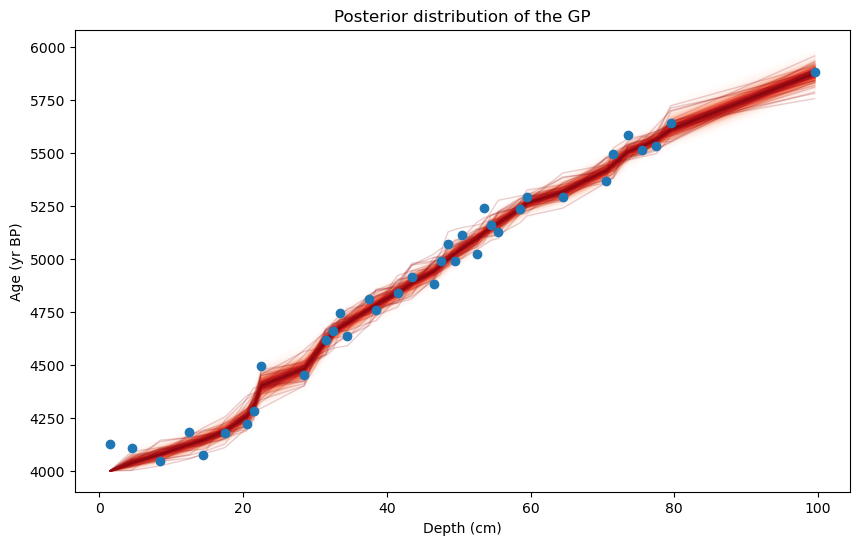

In [6]:
samples = trace.posterior['f'].stack(sample=("chain", "draw")).T
fig, ax = plt.subplots(figsize=(10, 6))
pm.gp.util.plot_gp_dist(ax=ax, samples=samples, x=X, samples_alpha=0.2, fill_alpha=0.2)
ax.set_title("Posterior distribution of the GP")
ax.set_xlabel("Depth (cm)")
ax.set_ylabel("Age (yr BP)")
plt.plot(depth, y_obs, "o", label="Observed")
plt.show()

## Make slope and intercept learnable parameters

In [ ]:
n_grid = 100
depth_grid = np.linspace(depth.min(), depth.max(), n_grid).reshape(-1, 1)

prior_mean = (oldest_age - youngest_age) / (depth.max() - depth.min())

with pm.Model() as model:
    intercept = pm.Normal("intercept", mu=youngest_age, sigma=errors[np.argmin(y_obs)])
    slope = pm.Normal("slope", mu=prior_mean, sigma=5)

    cov = pm.gp.cov.ExpQuad(1, ls=1)
    gp = pm.gp.Latent(cov_func=cov)

    h = gp.prior("h", X=X)
    g = pm.Deterministic("g", pt.exp(h))

    dx = pt.concatenate([[0], X[1:,0] - X[:-1,0]])
    f = pm.Deterministic("f", intercept + slope * pt.cumsum(g * dx))

    pm.Normal("y_obs", mu=f, sigma=errors, observed=y_obs)

    # GP and f on fine grid for plotting
    h_grid = gp.conditional("h_grid", Xnew=depth_grid)
    g_grid = pt.exp(h_grid)
    dx_grid = pt.concatenate([[0], depth_grid[1:,0] - depth_grid[:-1,0]])
    f_grid = pm.Deterministic("f_grid", intercept + slope * pt.cumsum(g_grid * dx_grid))

In [ ]:
pymc_model = nutpie.compile_pymc_model(model)
trace = nutpie.sample(pymc_model, draws=100, chains=4)

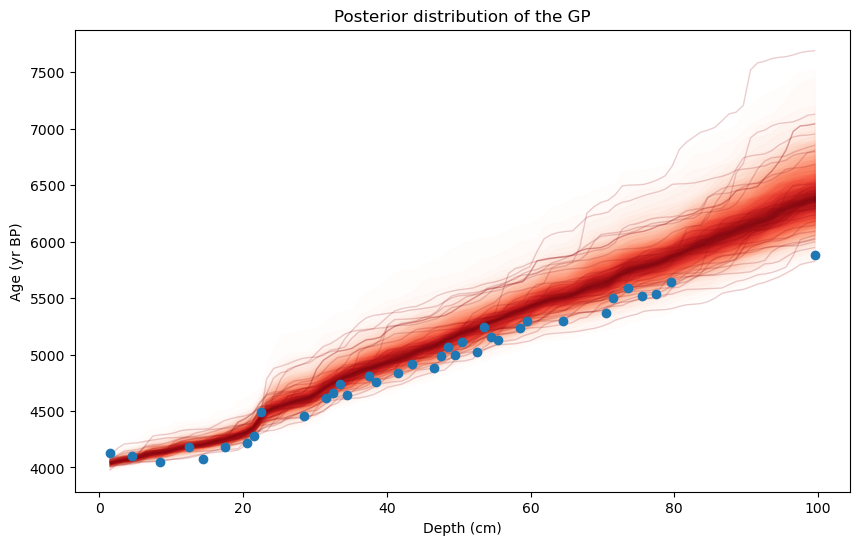

In [15]:
samples = trace.posterior['f_grid'].stack(sample=("chain", "draw")).T
fig, ax = plt.subplots(figsize=(10, 6))
pm.gp.util.plot_gp_dist(ax=ax, samples=samples, x=depth_grid, samples_alpha=0.2, fill_alpha=0.2)
ax.set_title("Posterior distribution of the GP")
ax.set_xlabel("Depth (cm)")
ax.set_ylabel("Age (yr BP)")
plt.plot(depth, y_obs, "o", label="Observed")
plt.show()

## Simulate from deepest to highest, instead

### Look at different potential Latent GPs

In [17]:
n_oos = 500
depth_grid = np.linspace(100, 1, n_oos).reshape(-1, 1)
prior_mean = (oldest_age - youngest_age) / (depth.max() - depth.min())

with pm.Model() as model:
    mean_func = pm.gp.mean.Constant(c=prior_mean)
    cov = pm.gp.cov.Matern32(input_dim=1, ls=10) + pm.gp.cov.WhiteNoise(sigma=1e-3)
    gp = pm.gp.Latent(cov_func=cov, mean_func=mean_func)

    f = gp.prior("f", X=X)

    f_grid = gp.conditional("f_grid", Xnew=depth_grid, jitter=1e-4)

In [20]:
with model:
    prior_pred_samples = pm.sample_prior_predictive(samples=5, var_names=["f", "f_grid"])

Sampling: [f_grid, f_rotated_]


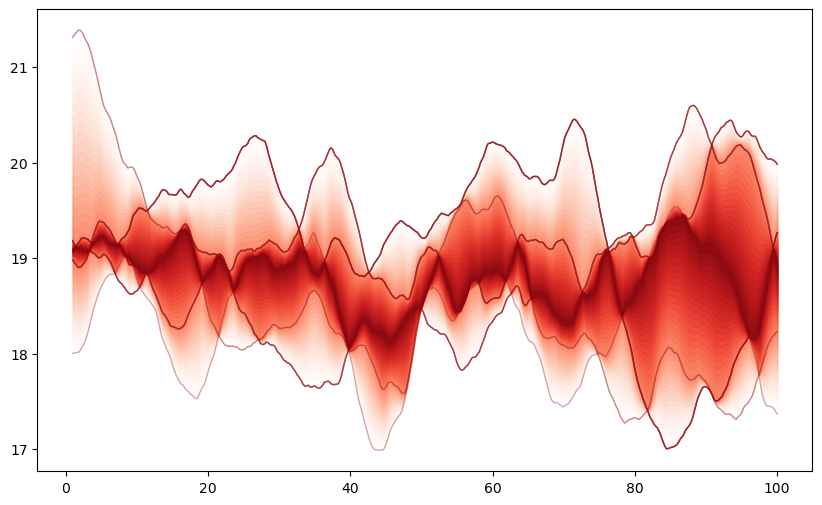

In [21]:
samples = prior_pred_samples.prior["f_grid"].sel(chain=0)
fig, ax = plt.subplots(figsize=(10, 6))
pm.gp.util.plot_gp_dist(ax=ax, samples=samples, x=depth_grid[::-1], samples_alpha=0.2, fill_alpha=0.2)
plt.show()

### Build full model

Let's have the GP sit at a mean of slope, and not exponentiate. This means that there is no hard positivity constraint on the accumulation rate, but the positive GP mean will discourage negative values.

In [109]:
n_oos = 200
depth_grid = np.linspace(100, 1, n_oos).reshape(-1, 1)
prior_mean = (oldest_age - youngest_age) / (depth.max() - depth.min())
oldest_age_err = errors[np.argmax(y_obs)]

with pm.Model() as model:
    intercept = pm.Normal("intercept", mu=oldest_age, sigma=oldest_age_err)
    mean_func = pm.gp.mean.Constant(c=prior_mean)
    cov = 50 * pm.gp.cov.Matern32(input_dim=1, ls=5) + pm.gp.cov.WhiteNoise(sigma=1e-3)
    gp = pm.gp.Latent(cov_func=cov, mean_func=mean_func)

    h = gp.prior("h", X=X_bot_up)

    dx = pt.concatenate([[0], (X_bot_up[1:,0] - X_bot_up[:-1,0])])
    f = pm.Deterministic(
        "f",
        intercept + pt.cumsum(h * dx)
    )

    pm.Normal("y_obs", mu=f, sigma=errors_bot_up, observed=y_bot_up)

    h_grid = gp.conditional("h_grid", Xnew=depth_grid, jitter=1e-4)
    dx_grid = pt.concatenate([[0], depth_grid[1:,0] - depth_grid[:-1,0]])
    f_grid = pm.Deterministic("f_grid", intercept + pt.cumsum(h_grid * dx_grid))

In [110]:
pymc_model = nutpie.compile_pymc_model(model)
trace = nutpie.sample(pymc_model, tune=100, draws=100, chains=2)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,200,0,0.03,1023
,200,0,0.04,1023


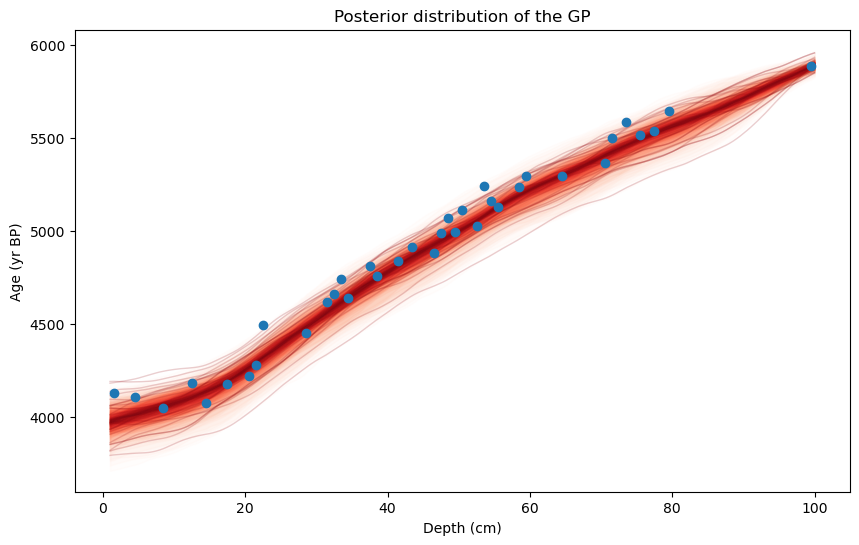

In [111]:
samples = trace.posterior['f_grid'].stack(sample=("chain", "draw")).T
fig, ax = plt.subplots(figsize=(10, 6))
pm.gp.util.plot_gp_dist(ax=ax, samples=samples, x=depth_grid, samples_alpha=0.2, fill_alpha=0.2)
ax.set_title("Posterior distribution of the GP")
ax.set_xlabel("Depth (cm)")
ax.set_ylabel("Age (yr BP)")
plt.plot(depth, y_obs, "o", label="Observed")
plt.show()

Text(0.5, 0, 'Depth (cm)')

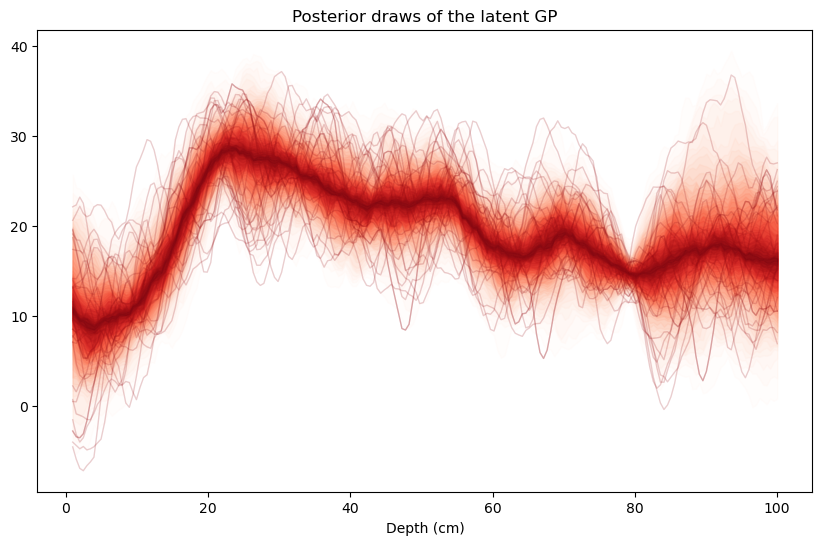

In [112]:
fig, ax = plt.subplots(figsize=(10, 6))
pm.gp.util.plot_gp_dist(ax=ax, samples=trace.posterior['h_grid'].stack(sample=("chain","draw")).T, 
                        x=depth_grid, samples_alpha=0.2, fill_alpha=0.2)
plt.title("Posterior draws of the latent GP")
plt.xlabel("Depth (cm)")

Text(0, 0.5, 'Accumulation rate (cm/yr)')

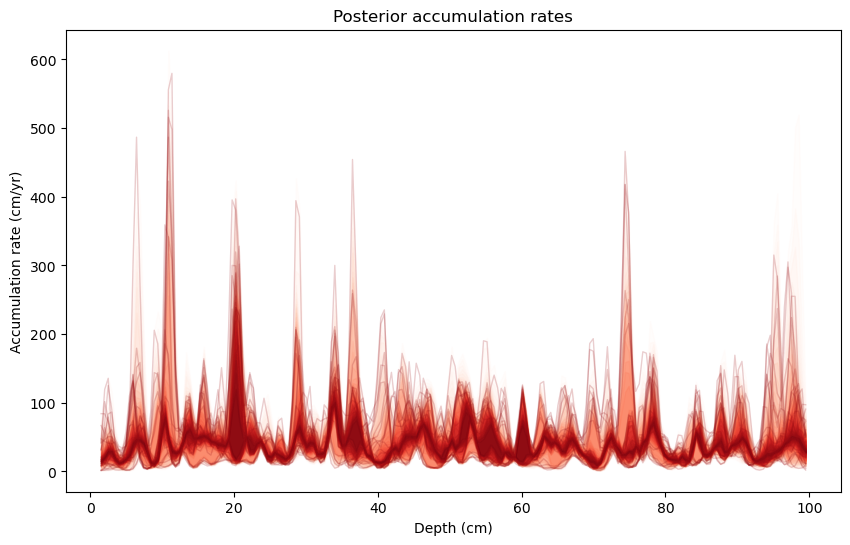

In [101]:
fig, ax = plt.subplots(figsize=(10, 6))
pm.gp.util.plot_gp_dist(ax=ax, samples=trace.posterior['g_grid'].stack(sample=("chain","draw")).T, 
                        x=depth_grid, samples_alpha=0.2, fill_alpha=0.2)
plt.title("Posterior accumulation rates")
plt.xlabel("Depth (cm)")
plt.ylabel("Accumulation rate (cm/yr)")

In [28]:
n_grid = 100
depth_grid = np.linspace(depth.min(), depth.max(), n_grid).reshape(-1, 1)[::-1,]
X = depth.reshape(-1, 1)[::-1]

prior_mean = (oldest_age - youngest_age) / (depth.max() - depth.min())

oldest_age_err = errors[np.argmax(y_obs)]

with pm.Model() as model:
    intercept = pm.Normal("intercept", mu=oldest_age, sigma=oldest_age_err)
    mean_func = pm.gp.mean.Constant(c=prior_mean)

    cov = 25 * pm.gp.cov.ExpQuad(1, ls=1)
    gp = pm.gp.Latent(cov_func=cov, mean_func=mean_func)

    h = gp.prior("h", X=X)

    dx = pt.concatenate([[0], (X[1:,0] - X[:-1,0])])
    f = pm.Deterministic(
        "f",
        intercept + pt.cumsum(h * dx)
    )

    pm.Normal("y_obs", mu=f, sigma=errors[::-1] / 4, observed=y_obs[::-1])

    h_grid = gp.conditional("h_grid", Xnew=depth_grid)
    dx_grid = pt.concatenate([[0], depth_grid[1:,0] - depth_grid[:-1,0]])
    f_grid = pm.Deterministic("f_grid", intercept + pt.cumsum(h_grid * dx_grid))

In [29]:
pymc_model = nutpie.compile_pymc_model(model)
trace = nutpie.sample(pymc_model, draws=50, chains=4)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,450,0,0.01,1023
,450,0,0.02,1023
,450,0,0.02,1023
,450,0,0.02,1023


<Axes: >

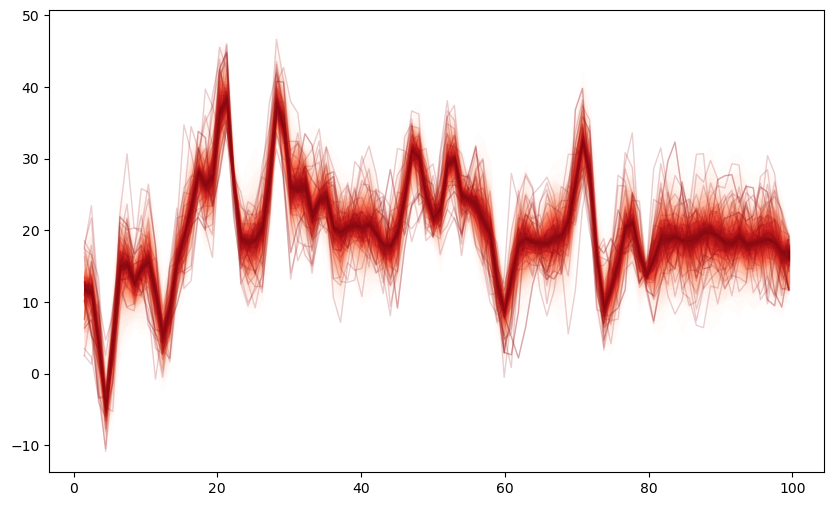

In [30]:
fig, ax = plt.subplots(figsize=(10, 6))
pm.gp.util.plot_gp_dist(ax=ax, samples=trace.posterior['h_grid'].stack(sample=("chain","draw")).T, 
                        x=depth_grid, samples_alpha=0.2, fill_alpha=0.2)

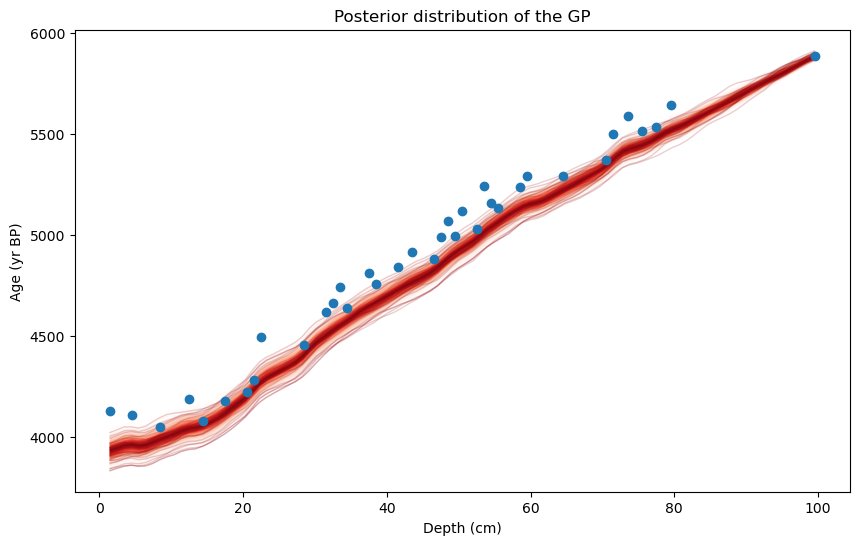

In [31]:
samples = trace.posterior['f_grid'].stack(sample=("chain", "draw")).T
fig, ax = plt.subplots(figsize=(10, 6))
pm.gp.util.plot_gp_dist(ax=ax, samples=samples, x=depth_grid, samples_alpha=0.2, fill_alpha=0.2)
ax.set_title("Posterior distribution of the GP")
ax.set_xlabel("Depth (cm)")
ax.set_ylabel("Age (yr BP)")
plt.plot(depth, y_obs, "o", label="Observed")
plt.show()